### CNN Input Layer to Facebook Pretrained Model for SV Genotyping

Notes:
- Uses InfoNCE Loss
- Includes padding for various number of sim images
- Visualization section at bottom of notebook
- Further notes/next steps throughout notebook
- AI was heavily used for code generation/debugging

Bug Fixes:
- OOM and Nan errors resolved
- Added chunking to fix OOM error with local drive path- due to the padding expansion images became too large
- Ranks now incorporated in loss/accuracy calculations

In [1]:
!pip install webdataset

In [2]:
import os
import webdataset as wds
from PIL import Image
from IPython.display import display
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import Counter
from transformers import AutoImageProcessor, AutoModel
from torchvision.transforms import Compose, Resize, Normalize
import huggingface_hub
import gdown
import numpy as np
import gc
from torch.utils.checkpoint import checkpoint

/home/tdrummey/.conda/envs/npsv3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print(f"Free: {torch.cuda.mem_get_info()[0]/1024**3:.2f} GB | Total: {torch.cuda.mem_get_info()[1]/1024**3:.2f} GB")

Free: 23.37 GB | Total: 23.57 GB


### COLAB VS ADA

In [5]:
# IF COLAB:
#from google.colab import userdata
#token = userdata.get('HF_TOKEN')
#huggingface_hub.login(token=token)

# IF VSCODE:
huggingface_hub.login(token=os.getenv("HF_TOKEN"))

### MODEL SELECTION

In [6]:
# VitL vs VitS+ Selection
S = "facebook/dinov3-vits16plus-pretrain-lvd1689m"
L = "facebook/dinov3-vitl16-pretrain-lvd1689m"
model_name = L

### PATH SELECTION

In [7]:
'''
GDOWN VS LOCAL PATH SELECTION
'''
# Download HG00733 example images stored in Google Drive
#gdown.download(id="1D9-HH7791QVucB0DL_a8DL8d0e5OZADW", output="images-0000.tar", quiet=False)
drive_dataset_path = "images-0000.tar"

# Path to local files
local_dataset_path = "/storage/mlinderman/projects/sv/npsv3-experiments/training/hgsvc3-hprc-2024-02-23.dipcall.passing.hg38.eval-images/HG00733/generator=coverage,pileup=unphased,simulation.replicates=1/images-{0000..0007}.tar"
#dataset = wds.WebDataset(local_dataset_path, shardshuffle=False).decode()

dataset_path = local_dataset_path

### CNN AND PREPROCESSING

In [ ]:
# --- 1. Define the Custom Input Layer ---
class CustomInputLayer(nn.Module):
    def __init__(self):
        # Learn nonlinear trends through ReLu activation function:
        super().__init__()
        # BatchNorm for the initial 7 channels
        self.bn = nn.BatchNorm2d(7)
        # First convolutional layer: 7 channels -> 32 channels
        self.conv1 = nn.Conv2d(in_channels=7, out_channels=32, kernel_size=1)
        self.relu1 = nn.ReLU()
        # Second convolutional layer: 32 channels -> 16 channels
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=16, kernel_size=1)
        self.relu2 = nn.ReLU()
        # Final convolutional layer: 16 channels -> 3 channels
        self.conv3 = nn.Conv2d(in_channels=16, out_channels=3, kernel_size=1)

    def forward(self, x):
        # Input shape expected: (B, C, H, W) where C=7
        x = self.bn(x)
        x = self.relu1(self.conv1(x))
        x = self.relu2(self.conv2(x))
        return self.conv3(x)

# --- 2. Initialize DINOv3 Model and Processor (Frozen) ---

# Use float32 precision for the DINO model and preprocessing pipeline.
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dino_processor = AutoImageProcessor.from_pretrained(model_name)
dino_model = AutoModel.from_pretrained(model_name, torch_dtype=torch.float32) # just dtype, no torch_
dino_model.eval()
dino_model.config.use_cache = False

# Enable gradient checkpointing so the large ViT can fit in VRAM during backprop.
# dino_model.gradient_checkpointing_enable()

# FREEZE DINO PARAMS
for param in dino_model.parameters():
    param.requires_grad = False

dino_model.to(device)
custom_input_converter = CustomInputLayer().to(device)


# --- 3. Define Differentiable Preprocessing ---

def full_dino_preprocess(raw_data_tensor, custom_input_converter, dino_processor, device):
    # 1. Map raw data tensor to device safely
    img_tensor = raw_data_tensor.to(device)


    # 2. Permute layout if it's currently (B, H, W, C) to channels-first (B, C, H, W)
    # The CustomInputLayer now expects 7 channels directly, so no feature expansion needed.
    if img_tensor.shape[-1] == 7:
        img_tensor = img_tensor.permute(0, 3, 1, 2).float()

    # 3. Project channels down to 3 using trainable layer (Gradients active here!)
    processed_3ch_tensor = custom_input_converter(img_tensor)

    # 4. Sigmoid activation to scale outputs to [0, 1]
    processed_3ch_tensor_normalized = torch.sigmoid(processed_3ch_tensor)

    # 5. 100% Differentiable Resize using native PyTorch functional interpolate
    resized_tensor = F.interpolate(
        processed_3ch_tensor_normalized,
        size=(128, 128),
        mode='bilinear',
        align_corners=False
    )

    # 6. 100% Differentiable Normalization using native tensor broadcasting
    mean = torch.tensor(dino_processor.image_mean, device=device).view(1, 3, 1, 1)
    std = torch.tensor(dino_processor.image_std, device=device).view(1, 3, 1, 1)

    normalized_tensor = (resized_tensor - mean) / std

    # Return the tensor retaining full history tracking
    return normalized_tensor

# --- 4. WebDataset Pipeline Helpers ---

if not os.path.exists(dataset_path):
    print(f"Downloading {dataset_path} from Google Drive...") # Should only download from GDrive if path to local DNE
    gdown.download(id="1D9-HH7791QVucB0DL_a8DL8d0e5OZADW", output=dataset_path, quiet=False) # COMMENT OUT
else:
    print(f"{dataset_path} already exists.")

def extract_data(sample):
    real_image = torch.from_numpy(sample["image.npy.gz"]).float()
    sim_images = torch.from_numpy(sample["sim.images.npy.gz"]).float() # G, R, H, W, C
    label = torch.tensor(sample["label.cls"], dtype=torch.long)

    if "label.rank.npy" in sample:
        rank_label = torch.from_numpy(sample["label.rank.npy"]).long()
    else:
        rank_label = torch.zeros(sim_images.shape[0], dtype=torch.long)
        if label.item() >= 0:
            rank_label[label.item()] = 1

    return real_image, sim_images, label, rank_label

'''
AI created custom_collate_fn to handle variable G sizes by padding with zeros and creating a mask to ignore padded entries during loss calculation. This allows batching without OOM errors while preserving all valid data.
'''
def custom_collate_fn(batch_list):
    real_imgs_batch = []
    sim_imgs_to_pad = []
    labels_batch = []
    rank_labels_to_pad = []
    max_G_in_batch = 0
    valid_G_counts = [] # Track original sizes

    for real_img_raw, sim_imgs_raw_full, label_raw, rank_label_raw in batch_list:
        real_imgs_batch.append(real_img_raw)
        sim_imgs_single_replicate = sim_imgs_raw_full[:, 0, :, :, :]
        sim_imgs_to_pad.append(sim_imgs_single_replicate)
        labels_batch.append(label_raw)
        rank_labels_to_pad.append(rank_label_raw)

        current_G = sim_imgs_single_replicate.shape[0]
        valid_G_counts.append(current_G)
        max_G_in_batch = max(max_G_in_batch, current_G)

    real_imgs_batched = torch.stack(real_imgs_batch, dim=0)
    labels_batched = torch.stack(labels_batch, dim=0)

    padded_sim_imgs_for_batch = []
    padded_rank_labels_for_batch = []
    padding_masks = []

    for i, sim_imgs_single_sample in enumerate(sim_imgs_to_pad):
        current_G = valid_G_counts[i]
        padding_needed = max_G_in_batch - current_G

        # Create a boolean mask: True for valid variants, False for padding
        sample_mask = torch.zeros(max_G_in_batch, dtype=torch.bool)
        sample_mask[:current_G] = True
        padding_masks.append(sample_mask)

        if padding_needed > 0:
            padding_tensor = torch.zeros(
                padding_needed,
                sim_imgs_single_sample.shape[1],
                sim_imgs_single_sample.shape[2],
                sim_imgs_single_sample.shape[3],
                dtype=sim_imgs_single_sample.dtype
            )
            padded_sim_imgs = torch.cat([sim_imgs_single_sample, padding_tensor], dim=0)
            padded_sim_imgs_for_batch.append(padded_sim_imgs)

            rank_padding_tensor = torch.zeros(padding_needed, dtype=rank_labels_to_pad[i].dtype)
            padded_rank_labels = torch.cat([rank_labels_to_pad[i], rank_padding_tensor], dim=0)
            padded_rank_labels_for_batch.append(padded_rank_labels)
        else:
            padded_sim_imgs_for_batch.append(sim_imgs_single_sample)
            padded_rank_labels_for_batch.append(rank_labels_to_pad[i])

    sim_imgs_batched = torch.stack(padded_sim_imgs_for_batch, dim=0)
    rank_labels_batched = torch.stack(padded_rank_labels_for_batch, dim=0)
    padding_masks_batched = torch.stack(padding_masks, dim=0)

    return real_imgs_batched, sim_imgs_batched, labels_batched, rank_labels_batched, padding_masks_batched

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 415/415 [00:00<00:00, 54120.89it/s]


/storage/mlinderman/projects/sv/npsv3-experiments/training/hgsvc3-hprc-2024-02-23.dipcall.passing.hg38.eval-images/HG00733/generator=coverage,pileup=unphased,simulation.replicates=1/images-{0000..0007}.tar already exists.


### Post-DINO Convolutional Layers

In [ ]:
'''
"MLP Projection Head"
Written by AI, multi layer perceptron (MLP) projection head for post-DINO embeddings. This head is designed to take the output embeddings from the DINO model and project them into a lower-dimensional space suitable for downstream tasks, such as contrastive learning or classification. The MLP consists of two linear layers with a ReLU activation in between, followed by normalization to ensure the output embeddings have unit length.
'''
class PostDinoConvLayer(nn.Module):
    '''
    # AI also suggested convolution option
    class PostDinoSpatialConvHead(nn.Module):
    def __init__(self, input_dim, output_dim=None, grid_size=14):
        super().__init__()
        if output_dim is None:
            output_dim = input_dim
            
        self.grid_size = grid_size  # e.g., 14 for a 224x224 image with patch_size=16

        # Apply 2D convolutions over actual spatial dimensions
        self.conv1 = nn.Conv2d(in_channels=input_dim, out_channels=input_dim // 2, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(input_dim // 2)
        
        self.conv2 = nn.Conv2d(in_channels=input_dim // 2, out_channels=output_dim, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(output_dim)
        
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):
        # x shape from DINO patch tokens: (B, Num_Patches, Embedding_Dim) -> e.g., (B, 196, 768)
        B, N, C = x.shape
        
        # 1. Reshape to image-like grid: (B, C, H, W) -> (B, 768, 14, 14)
        x = x.transpose(1, 2).reshape(B, C, self.grid_size, self.grid_size)
        
        # 2. Convolve over true spatial space
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        
        # 3. Pool spatially to get a global vector: (B, output_dim, 1, 1) -> (B, output_dim)
        x = self.global_avg_pool(x).view(B, -1)
        
        return F.normalize(x, p=2, dim=1)
    '''
    def __init__(self, input_dim, output_dim=None):
        super().__init__()
        if output_dim is None:
            output_dim = input_dim

        # Standard non-linear projection head for contrastive learning
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.BatchNorm1d(input_dim),
            nn.ReLU(),
            nn.Linear(input_dim, output_dim)
        )

    def forward(self, x):
        # x shape: (B, input_dim)
        x = self.mlp(x)
        # Match original DINO embedding normalization space
        return F.normalize(x, p=2, dim=1)

# Get DINO output embedding dimension
dino_output_dim = dino_model.config.hidden_size
# Initialize the post-DINO convolutional layer
post_dino_conv_layer = PostDinoConvLayer(input_dim=dino_output_dim).to(device)

### InfoNCE LOSS FUNCTION

In [10]:
'''
InfoNCE class from repo
'''
class InfoNCE(nn.Module):
    """
    Implements the InfoNCE loss for contrastive learning using precomputed similarity scores

    This formulation encourages positive pairs (query-support with label=1) to have higher
    similarity scores than negative pairs (label=0) within each variant group. It applies
    temperature scaling and uses log-ratio separation between positives and all negatives.

    Args:
        temperature (float, optional): Scaling factor applied to similarity scores before exponentiation. Default is 0.07.
        pos_weight (float, optional): Weight to apply to the loss of samples where the true label is not 0. Default is 1.0.

    Inputs:
        metric (torch.Tensor): A 2D nested tensor of shape(|variants|, j1=|support|) with distances between query and support embeddings.
        target (torch.Tensor): A 2D tensor of rank values per support candidate where 0 is negative, 1 is fully correct,
            and larger values receive diminishing positive credit for partial correctness.
        original_labels (torch.Tensor): The original true labels for each sample in the batch. Used for weighting.

    Returns:
        tuple[torch.Tensor]: Scalar tensor representing the average InfoNCE loss across variant groups and the number of variants in batch
    """

    def __init__(self, temperature=0.07, pos_weight=1.0):
        super().__init__()
        self.temperature = temperature
        self.pos_weight = pos_weight

    def forward(self, metric: torch.Tensor, target: torch.Tensor, original_labels: torch.Tensor):
        target = torch.where(torch.eq(target, 1) | torch.eq(target, 2), 1, 0)
        metric = metric / self.temperature  # Scale the similarity scores by the temperature

        loss = torch.tensor([0.0], dtype=metric.dtype, device=metric.device)
        total_variants_processed_weighted = 0.0 # ADDED

        for variant_metric, variant_target, original_label in zip(metric.unbind(), target.unbind(), original_labels.unbind(), strict=True): # ADDED ORIGINAL_LABELS... SHOULDNT NEED?
            negative_mask = variant_target == 0
            negatives = variant_metric[negative_mask]
            positives = variant_metric[torch.logical_not(negative_mask)]

            # Add this check to prevent NaN from empty positive tensors
            if positives.numel() == 0:
                continue

            # Compute log(softmax) using log-sum-exp trick (similar to log_softmax) to ensure numerical stability
            max_value = torch.max(variant_metric)
            numerator = positives - max_value

            # Normalize by the number of positives "outside the log". This is the approach described in the SupCon paper.
            # Normalizing seems to improve learning and accuracy relative to just a "sum".
            variant_loss= torch.mean(
                numerator - torch.log(torch.exp(numerator) + torch.sum(torch.exp(negatives - max_value)) + 1e-8)
            )

            # Apply positive weight if the original_label is not 0
            current_weight = self.pos_weight if original_label.item() != 0 else 1.0 # ADDED
            loss += variant_loss * current_weight
            total_variants_processed_weighted += current_weight # ADDED

        return -loss / metric.size(0), metric.size(0)
        '''
        # The following if statements were added by AI, going to try original return statement instead. This option basically normalizes the positive weight by its potency?? Not sur ewhich to use.
        if total_variants_processed_weighted > 0:
            return -loss / total_variants_processed_weighted, metric.size(0)
        else:
            return -loss, metric.size(0)
        '''


### TRAINING CNN INPUT LAYER


In [ ]:
'''
Retrain with NCE

- 2 layer nonlinear transformation at beginning AND end with activation function
- Try unfreezing certain layers...
- TRY OPENAI CLIP: https://github.com/openai/CLIP
- Try visualizing spectrum of the 7 channels in images rather than which channels being used
- Turn to an application
- Add more visuals for comparison
- Look into how to incorporate code into repo (Lightning is wrapper for PyTorch that simplifies training loops, logging, and checkpointing used in the repo)

- Adjust parameters (Default should be 1000 samples, 15 epochs, 1.3e-2 LR and 1.0 pos_weight)
- Find way to save models for comparison, compare various versions we have already
- Other loss models, RINCE rank ordering, fractional pos_weight?
- Pairwise image comparision (image differences like BeatNet)
- Fine tuning w LORA?
- Lejepa
- Accuracy and loss graphs (less necessary now that gradients are stable)
- Binary classifier?
- Use loaders from npsv3 repo
- Trained a second model on a second 3 channels, then add layer that weighs the similarity scores from each for a single sample... But I think this is kinda the same as just adding transformation layers
- Why do alternating epochs use slightly different amount of space in memory? Is this a bug?
'''

# Configuration parameters
dino_chunk_size = 16  # Size of image
batch_size = 16  # How many images pushed to ViT at given time to prevent OOM
max_samples_per_epoch = 1200
num_epochs_infonce = 15
learning_rate_infonce = 1.3e-2  # 5e-5 #2e-4 .005 .01
pos_weight_infonce = 1.0 # Weight for positive samples (true_label != 0)

# Initialize custom input converter
custom_input_converter_infonce = CustomInputLayer().to(device)
# Include parameters from both custom_input_converter and post_dino_conv_layer in the optimizer
optimizer_infonce = torch.optim.Adam(
    list(custom_input_converter_infonce.parameters()) + list(post_dino_conv_layer.parameters()),
    lr=learning_rate_infonce
)
infonce_criterion = InfoNCE(temperature=0.07, pos_weight=pos_weight_infonce) # Pass pos_weight

print(f"\nStarting InfoNCE training for {num_epochs_infonce} epochs...")

# Initialize dataloader and shuffle for InfoNCE training
# Use a small shardshuffle to avoid warning and keep memory predictable.
dataset_infonce = (
    wds.WebDataset(dataset_path, shardshuffle=False)
    .decode()
    .map(extract_data)
    .slice(0, max_samples_per_epoch)  # Limit to max_samples_per_epoch
)

dataloader_infonce = wds.WebLoader(
    dataset_infonce,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=custom_collate_fn,
)

# Clear memory graphs
torch.cuda.empty_cache()
gc.collect()

# Simple wrapper function required by the PyTorch checkpoint engine
def run_dino_checkpoint(inputs):
    outputs = dino_model(pixel_values=inputs).pooler_output
    return F.normalize(outputs.float(), p=2, dim=1).to(torch.float32)


scaler = torch.amp.GradScaler('cuda') # FIX FOR NAN VALUES (underflow)
for epoch in range(num_epochs_infonce):
    custom_input_converter_infonce.train()
    post_dino_conv_layer.train() # Set post_dino_conv_layer to train mode
    dino_model.eval()

    total_loss_infonce = 0.0
    correct_matches_infonce = 0
    total_samples_processed_infonce = 0

    for batch_idx, (real_imgs_raw, sim_imgs_raw, labels, rank_labels, padding_masks) in enumerate(dataloader_infonce):
        if total_samples_processed_infonce >= max_samples_per_epoch:
            break

        optimizer_infonce.zero_grad()
        # Send everything to device
        real_imgs_raw = real_imgs_raw.to(device)
        sim_imgs_raw = sim_imgs_raw.to(device)
        labels = labels.to(device)
        rank_labels = rank_labels.to(device)
        padding_masks = padding_masks.to(device)

        # ==========================================
        # 1. FORWARD & CHECKPOINT PASS: REAL IMAGES
        # ==========================================
        with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
            # Uses native differentiable preprocessor
            processed_real_inputs = full_dino_preprocess(
                real_imgs_raw, custom_input_converter_infonce, dino_processor, device
            )

            # Checkpoint runs the frozen DINO without saving intermediate activations
            dino_real_embeddings = checkpoint(
                run_dino_checkpoint,
                processed_real_inputs,
                use_reentrant=False  # Modern non-reentrant graph handling AI RECOMMENDED CHANGING THIS TO TRUE
            )
            # Apply post-DINO convolutional layer
            real_embeddings = post_dino_conv_layer(dino_real_embeddings)

        # ==========================================
        # 2. FORWARD & CHECKPOINT PASS: SIMULATED IMAGES
        # ==========================================

        # We now need chunking for the sim images due to their larger size (G variants per sample). We will reshape to combine batch and G dimensions, process through the preprocessor and DINO in chunks, then reshape back to separate batch and G for loss calculation.
        bs, G, H, W, C = sim_imgs_raw.shape
        sim_imgs_raw_reshaped = sim_imgs_raw.reshape(bs * G, H, W, C)

        with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
            processed_sim_inputs_flat = full_dino_preprocess(
                sim_imgs_raw_reshaped, custom_input_converter_infonce, dino_processor, device
            )

            # Implement the same chunking strategy used in evaluation
            dino_sim_embeddings_list = []
            num_sim_images = processed_sim_inputs_flat.shape[0]

            for i in range(0, num_sim_images, dino_chunk_size):
                chunk = processed_sim_inputs_flat[i : i + dino_chunk_size]
                chunk_emb = checkpoint(
                    run_dino_checkpoint,
                    chunk,
                    use_reentrant=False
                )
                dino_sim_embeddings_list.append(chunk_emb)

            dino_sim_embeddings_flat = torch.cat(dino_sim_embeddings_list, dim=0)
            # Apply post-DINO convolutional layer
            sim_embeddings_flat = post_dino_conv_layer(dino_sim_embeddings_flat)

        sim_embeddings = sim_embeddings_flat.view(bs, G, -1)

        # ==========================================
        # 3. LOSS & STANDARD BACKWARD
        # ==========================================
        similarity_scores = torch.bmm(
            real_embeddings.unsqueeze(1),
            sim_embeddings.permute(0, 2, 1)
        ).squeeze(1).float()

        similarity_scores = similarity_scores.float()

        similarity_scores[~padding_masks] = float('-inf')

        loss, num_variants = infonce_criterion(similarity_scores, rank_labels, labels) # Pass original labels for weighting

        # Nan checks
        if torch.isnan(loss):
            print("LOSS IS NAN")
        if torch.isnan(similarity_scores).any():
            print("similarity_scores contain NaN")
        '''
        print(
            similarity_scores.min().item(),
            similarity_scores.max().item()
        )
        '''

        # FIX FOR UNDERFLOW:

        # 1. Scale the loss and call backward
        scaler.scale(loss).backward()
        # 2. Unscale BEFORE clipping gradients (crucial!)
        scaler.unscale_(optimizer_infonce)
        torch.nn.utils.clip_grad_norm_(
            list(custom_input_converter_infonce.parameters()) + list(post_dino_conv_layer.parameters()),
            max_norm=1.0
        )
        # 3. Step the optimizer using the scaler
        scaler.step(optimizer_infonce)
        # 4. Update the scaler for the next iteration
        scaler.update()

        # Track Metrics
        total_loss_infonce += loss.item() * num_variants
        top_guess = torch.argmax(similarity_scores, dim=1)
        guess_rank = torch.gather(rank_labels.to(device), 1, top_guess.unsqueeze(1)).squeeze(1)
        correct_mask = (guess_rank == 1) | (guess_rank == 2)
        correct_matches_infonce += correct_mask.sum().item()
        total_samples_processed_infonce += labels.size(0) # AI recs not using bs?

        # Clean batch structures
        del processed_real_inputs, dino_real_embeddings, real_embeddings, sim_imgs_raw_reshaped
        del processed_sim_inputs_flat, dino_sim_embeddings_flat, sim_embeddings_flat, sim_embeddings, similarity_scores
        if batch_idx % 10 == 0:
            torch.cuda.empty_cache()

    if total_samples_processed_infonce > 0:
        avg_loss_infonce = total_loss_infonce / total_samples_processed_infonce
        accuracy_infonce = correct_matches_infonce / total_samples_processed_infonce
    else:
        avg_loss_infonce, accuracy_infonce = 0.0, 0.0

    print(f"InfoNCE Epoch {epoch+1}/{num_epochs_infonce}, Loss: {avg_loss_infonce:.4f}, Match Accuracy: {accuracy_infonce:.4f}, Max Samples: {max_samples_per_epoch}, LR: {learning_rate_infonce}, pos_weight: {pos_weight_infonce}")

    # Slicing is '[:16]' for 16 input channels - not especially useful...
    conv_weights = custom_input_converter_infonce.conv3.weight.data
    print(f"R Mapping Weights (First 16 elements): {conv_weights[0].flatten()[:16].tolist()}")
    print(f"G Mapping Weights (First 16 elements): {conv_weights[1].flatten()[:16].tolist()}")
    print(f"B Mapping Weights (First 16 elements): {conv_weights[2].flatten()[:16].tolist()}")
    print(f"Free: {torch.cuda.mem_get_info()[0]/1024**3:.2f} GB | Total: {torch.cuda.mem_get_info()[1]/1024**3:.2f} GB")
    print("-" * 60)

print("InfoNCE training complete")


Starting InfoNCE training for 15 epochs...
InfoNCE Epoch 1/15, Loss: 1.3269, Match Accuracy: 0.4825, Max Samples: 1200, LR: 0.013, pos_weight: 1.0
R Mapping Weights (First 16 elements): [0.10934378951787949, 0.013202320784330368, 0.01973867230117321, 0.16121719777584076, -0.009819895029067993, -0.2999159097671509, 0.09998949617147446, 0.1379745602607727, 0.17390617728233337, 0.027754565700888634, -0.025625118985772133, 0.185055673122406, 0.1894807368516922, -0.07261797040700912, 0.1033451035618782, -0.15467223525047302]
G Mapping Weights (First 16 elements): [-0.09787203371524811, 0.03834773972630501, -0.20679254829883575, -0.0955527126789093, 0.11736662685871124, 0.03320808708667755, 0.08723670989274979, -0.08800814300775528, 0.0187628623098135, -0.18245339393615723, 0.03456607833504677, -0.18415680527687073, -0.19064342975616455, 0.09378544241189957, -0.13591454923152924, -0.09807302057743073]
B Mapping Weights (First 16 elements): [-0.1270696520805359, 0.15926077961921692, 0.089227

### TESTING

In [ ]:
'''
Validation on unseen data for InfoNCE model
- Confusion matrix now reflects traditional confusion matrix methods for tp tn fp fn.
- Fix print statements so that they reflect the actual sample number rather than just adding...
'''

test_size = 2000

print("\nStarting evaluation on the next " + str(test_size) + " samples...")

custom_input_converter_infonce.eval()
post_dino_conv_layer.eval() # Set post_dino_conv_layer to eval mode
dino_model.eval()

total_correct_guesses = 0
total_evaluated_samples = 0
correctPos = 0
correctNeg = 0
# Confusion Matrix vars
tp = 0
tn = 0
fp = 0
fn = 0

sample_number_offset = max_samples_per_epoch # Start after the samples used for training

# Create a new dataset and dataloader for evaluation, skipping the initial samples
eval_dataset = (
    wds.WebDataset(dataset_path, shardshuffle=False)
    .decode()
    .map(extract_data)
    #.slice(0, 400)
    .slice(sample_number_offset, sample_number_offset + test_size) # Use .slice() to skip and take the next test_size samples
)
eval_dataloader = wds.WebLoader(eval_dataset, batch_size=batch_size, shuffle=False, collate_fn=custom_collate_fn)

with torch.no_grad():
    for batch_idx, (real_imgs_raw, sim_imgs_raw, labels, rank_labels, padding_masks) in enumerate(eval_dataloader):
        # 1. Forward pass on real images
        processed_real_inputs = full_dino_preprocess(
            real_imgs_raw, custom_input_converter_infonce, dino_processor, device
        )
        dino_real_embeddings = dino_model(pixel_values=processed_real_inputs).pooler_output
        dino_real_embeddings = F.normalize(dino_real_embeddings, p=2, dim=1)
        real_embeddings = post_dino_conv_layer(dino_real_embeddings)

        # 2. Reshape simulated images safely
        bs, G, H, W, C = sim_imgs_raw.shape
        sim_imgs_raw_reshaped = sim_imgs_raw.reshape(bs * G, H, W, C)

        processed_sim_inputs_flat = full_dino_preprocess(
            sim_imgs_raw_reshaped, custom_input_converter_infonce, dino_processor, device
        )

        # 3. Chunked Inference for simulated images to manage VRAM
        dino_sim_embeddings_list = []
        num_sim_images = processed_sim_inputs_flat.shape[0]

        for i in range(0, num_sim_images, dino_chunk_size):
            chunk = processed_sim_inputs_flat[i : i + dino_chunk_size]
            chunk_output = dino_model(pixel_values=chunk).pooler_output
            chunk_output = F.normalize(chunk_output, p=2, dim=1)
            dino_sim_embeddings_list.append(chunk_output)

        dino_sim_embeddings_flat = torch.cat(dino_sim_embeddings_list, dim=0)
        sim_embeddings_flat = post_dino_conv_layer(dino_sim_embeddings_flat)

        # 4. Unflatten back to batch spaces
        embedding_dim = sim_embeddings_flat.shape[-1]
        sim_embeddings = sim_embeddings_flat.view(bs, G, embedding_dim)

        # 5. Compute contrastive similarity scores
        similarity_scores = torch.bmm(
            real_embeddings.unsqueeze(1),
            sim_embeddings.permute(0, 2, 1)
        ).squeeze(1)

        # Apply padding mask to prevent guessing invalid padded indices
        padding_masks_batch = padding_masks.to(device)
        similarity_scores[~padding_masks_batch] = float('-inf')

        # 6. Get predicted labels and evaluate
        topGuess = torch.argmax(similarity_scores, dim=1)

        for i in range(real_imgs_raw.shape[0]): # Iterate through samples in the current batch
            primary_indices = (rank_labels[i] == 1).nonzero(as_tuple=True)[0]
            secondary_indices = (rank_labels[i] == 2).nonzero(as_tuple=True)[0]
            p_val = primary_indices[0].item() if len(primary_indices) > 0 else -1
            s_val = secondary_indices[0].item() if len(secondary_indices) > 0 else -1

            guess = topGuess[i].item()
            rank_of_guess = rank_labels[i, guess].item()
            if rank_of_guess == 1 or rank_of_guess == 2:
                correct = True
            else:
                correct = False

            if correct:
                total_correct_guesses += 1
                if guess == 0:
                    correctNeg += 1
                else:
                    correctPos += 1

            # Confusion matrix if statements

            if guess == 0:
                if p_val == 0:
                    tn += 1
                else:
                    fn += 1
            else:
                if p_val == 0:
                    fp += 1
                else:
                    tp += 1


            total_evaluated_samples += 1
            current_accuracy = (total_correct_guesses / total_evaluated_samples) * 100

            print(f"Sample {sample_number_offset + total_evaluated_samples}: Guess={guess}, Actual={p_val}, Secondary Label={s_val}, Accuracy={current_accuracy:.2f}%")

print(f"\nEvaluation complete. Total Accuracy on {total_evaluated_samples} samples: {(total_correct_guesses / total_evaluated_samples) * 100:.2f}%")
print("\n")
print("Confusion Matrix:")
print(f"TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")
print("\n")
print("Number of Positive Samples = " + str(tp + fn))
print("Number of Negative Samples = " + str(tn + fp))
print("True Positive Accuracy: " + str((tp / (tp + fn)) * 100))
print("True Negative Accuracy: " + str((tn / (tn + fp)) * 100))
print("Positive Sample Accuracy: " + str(correctPos / (tp + fn) * 100))
print("Negative Sample Accuracy: " + str(correctNeg / (tn + fp) * 100))


Starting evaluation on the next 2000 samples...
Sample 1201: Guess=4, Actual=7, Secondary Label=5, Accuracy=0.00%
Sample 1202: Guess=2, Actual=1, Secondary Label=2, Accuracy=50.00%
Sample 1203: Guess=12, Actual=6, Secondary Label=3, Accuracy=66.67%
Sample 1204: Guess=2, Actual=1, Secondary Label=2, Accuracy=75.00%
Sample 1205: Guess=3, Actual=3, Secondary Label=-1, Accuracy=80.00%
Sample 1206: Guess=1, Actual=2, Secondary Label=1, Accuracy=83.33%
Sample 1207: Guess=2, Actual=2, Secondary Label=1, Accuracy=85.71%
Sample 1208: Guess=2, Actual=1, Secondary Label=2, Accuracy=87.50%
Sample 1209: Guess=1, Actual=2, Secondary Label=1, Accuracy=88.89%
Sample 1210: Guess=2, Actual=1, Secondary Label=2, Accuracy=90.00%
Sample 1211: Guess=2, Actual=2, Secondary Label=1, Accuracy=90.91%
Sample 1212: Guess=2, Actual=2, Secondary Label=1, Accuracy=91.67%
Sample 1213: Guess=2, Actual=1, Secondary Label=2, Accuracy=92.31%
Sample 1214: Guess=3, Actual=3, Secondary Label=-1, Accuracy=92.86%
Sample 1215

### PREVIOUS RESULTS

In [13]:
'''
'''

'\n'

In [14]:
def predict_single_sample(img_data):
    with torch.no_grad():
        real_img_tensor = torch.from_numpy(np.asarray(img_data["image.npy.gz"])).float()
        sim_img_array = np.asarray(img_data["sim.images.npy.gz"])

        if real_img_tensor.ndim == 3:
            real_img_tensor = real_img_tensor.unsqueeze(0)

        if sim_img_array.ndim == 5:
            sim_img_tensor = torch.from_numpy(sim_img_array[:, 0, :, :, :]).float()
        else:
            sim_img_tensor = torch.from_numpy(sim_img_array).float()

        if sim_img_tensor.ndim == 4:
            sim_img_tensor = sim_img_tensor.unsqueeze(0)

        real_imgs_raw = real_img_tensor.to(device)
        sim_imgs_raw = sim_img_tensor.to(device)

        processed_real_inputs = full_dino_preprocess(
            real_imgs_raw, custom_input_converter_infonce, dino_processor, device
        )
        dino_real_embeddings = dino_model(pixel_values=processed_real_inputs).pooler_output
        dino_real_embeddings = F.normalize(dino_real_embeddings, p=2, dim=1)
        real_embeddings = post_dino_conv_layer(dino_real_embeddings)

        bs, G, H, W, C = sim_imgs_raw.shape
        sim_imgs_raw_reshaped = sim_imgs_raw.reshape(bs * G, H, W, C)

        processed_sim_inputs_flat = full_dino_preprocess(
            sim_imgs_raw_reshaped, custom_input_converter_infonce, dino_processor, device
        )

        dino_sim_embeddings_list = []
        for i in range(0, processed_sim_inputs_flat.shape[0], dino_chunk_size):
            chunk = processed_sim_inputs_flat[i : i + dino_chunk_size]
            chunk_output = dino_model(pixel_values=chunk).pooler_output
            chunk_output = F.normalize(chunk_output, p=2, dim=1)
            dino_sim_embeddings_list.append(chunk_output)

        dino_sim_embeddings_flat = torch.cat(dino_sim_embeddings_list, dim=0)
        sim_embeddings_flat = post_dino_conv_layer(dino_sim_embeddings_flat)
        sim_embeddings = sim_embeddings_flat.view(bs, G, -1)

        similarity_scores = torch.bmm(
            real_embeddings.unsqueeze(1),
            sim_embeddings.permute(0, 2, 1)
        ).squeeze(1)

        padding_masks = torch.ones((1, sim_imgs_raw.shape[1]), dtype=torch.bool, device=device)
        similarity_scores[~padding_masks] = float('-inf')

        predicted_label = int(torch.argmax(similarity_scores, dim=1)[0].item())
    return predicted_label

In [15]:
'''
New Learned Display Function
- Note this is still just showing the distrubution (scaled) of the 3 channels- it would be more informative
to convert the original and weighted images in a way to actually see how the 7 channels are used, as noted in training section.
'''
def to_learned_display_image(image_array):
        with torch.no_grad():
            x = torch.from_numpy(np.asarray(image_array)).float()
            if x.ndim == 3:
                x = x.unsqueeze(0)
            # The CustomInputLayer now directly handles 7 channels and performs the transformation.
            if x.shape[-1] == 7:
                x = x.permute(0, 3, 1, 2) # Permute to (B, C, H, W)
            x = x.to(device, dtype=torch.float32)
            # Pass the input directly to the custom_input_converter_infonce instance
            projected = custom_input_converter_infonce(x)
            projected = torch.sigmoid(projected).squeeze(0).permute(1, 2, 0)
            projected = projected.detach().cpu().numpy()

            # Apply per-channel min-max scaling for better visualization
            for i in range(projected.shape[-1]): # Iterate over channels (assuming 3 channels: R, G, B)
                channel_min = projected[:, :, i].min()
                channel_max = projected[:, :, i].max()
                if channel_max > channel_min: # Avoid division by zero if channel is constant
                    projected[:, :, i] = (projected[:, :, i] - channel_min) / (channel_max - channel_min)
                else:
                    projected[:, :, i] = np.full_like(projected[:, :, i], 0.5) # If constant, set to mid-gray

            projected = np.clip(projected, 0, 1) # Ensure values are within [0, 1] after scaling
            projected = (projected * 255).astype(np.uint8)
        return Image.fromarray(projected)

### VISUALIZATION

Index: 501 True Label: 3 Predicted Label: 3


Fixed Channel Images (Real, True, Pred):


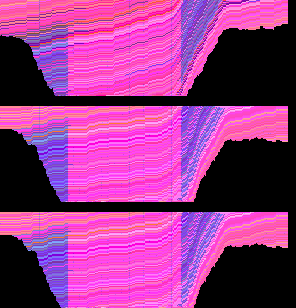

Learned Weight Images (Real, True, Pred):


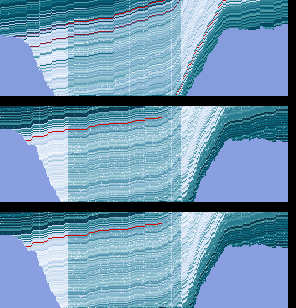

Index: 600 True Label: 2 Predicted Label: 2


Fixed Channel Images (Real, True, Pred):


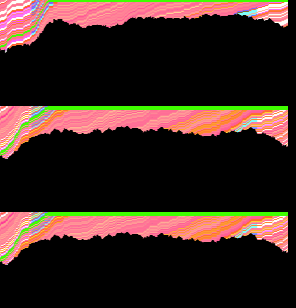

Learned Weight Images (Real, True, Pred):


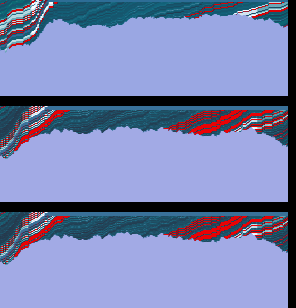

Index: 3000 True Label: 2 Predicted Label: 1


Fixed Channel Images (Real, True, Pred):


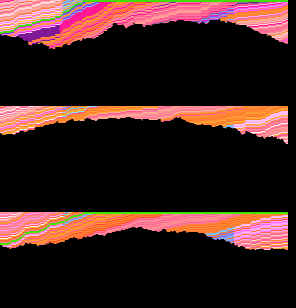

Learned Weight Images (Real, True, Pred):


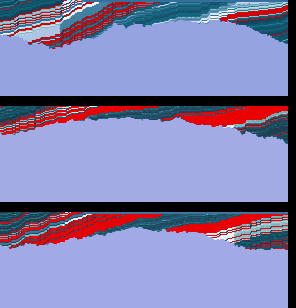

Index: 5000 True Label: 1 Predicted Label: 2


Fixed Channel Images (Real, True, Pred):


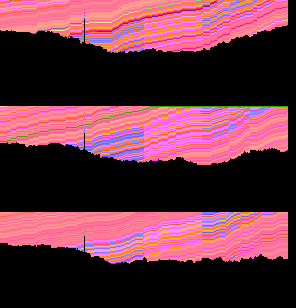

Learned Weight Images (Real, True, Pred):


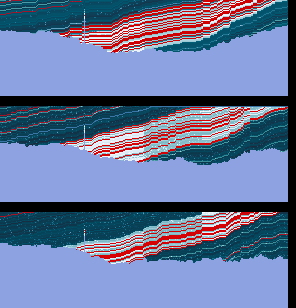

In [18]:
'''
Visualization
- Add more images to display- we need to compare the differences in images not just how well they match...
'''
dataset = wds.WebDataset(dataset_path, shardshuffle=False).decode()
def find_img(img_idx):
    for _i, image in enumerate(dataset):
        if _i == img_idx:
            return image

userContinue = "y"
while(userContinue == "y"):
    input_idx = int(input("Enter image index to visualize: "))
    img_idx = input_idx
    img_data = find_img(img_idx-1)
    img_label = img_data["label.cls"]

    sim_img_data = img_data["sim.images.npy.gz"][img_label][0]
    # Model Prediction
    predicted_label = predict_single_sample(img_data)
    pred_img_data = img_data["sim.images.npy.gz"][predicted_label][0]

    # ORIGINAL IMG
    real_img = Image.fromarray(img_data["image.npy.gz"][:, :, [0, 1, 5]])
    sim_img = Image.fromarray(sim_img_data[:, :, [0, 1, 5]])
    pred_img = Image.fromarray(pred_img_data[:, :, [0, 1, 5]])
    OGimg = Image.new(real_img.mode, (296, 96*3+20))
    OGimg.paste(real_img, (0, 0))
    OGimg.paste(sim_img, (0, 96+10))
    OGimg.paste(pred_img, (0, 2*96+20))

    # LEARNED WEIGHT IMG
    real_img = to_learned_display_image(img_data["image.npy.gz"])
    sim_img = to_learned_display_image(sim_img_data)
    pred_img = to_learned_display_image(pred_img_data)
    img = Image.new(real_img.mode, (296, 96*3+20))
    img.paste(real_img, (0, 0))
    img.paste(sim_img, (0, 96+10))
    img.paste(pred_img, (0, 2*96+20))

    print(f"Index: {img_idx} True Label: {img_label} Predicted Label: {predicted_label}")
    print("\n")
    print("Fixed Channel Images (Real, True, Pred):")
    display(OGimg)
    print("Learned Weight Images (Real, True, Pred):")
    display(img)

    userContinue = input("Continue? (y/n): ")